# World Cup

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "nalisha/fifa-world-cup-2022-match-performance-dataset"
)

print("Path to dataset files:", path)

c:\Users\yarah\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\yarah\.cache\kagglehub\datasets\nalisha\fifa-world-cup-2022-match-performance-dataset\versions\1


### Undertsanding the data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import requests
from PIL import Image
from io import BytesIO

In [26]:
data = pd.read_csv(path + "/Fifa_world_cup_matches.csv")
print(data.head())

# Some data cleaning
import re

data.columns = data.columns.str.replace(r'\s+', ' ', regex=True).str.strip()
data['possession team1'] = data['possession team1'].str.replace('%', '').astype(float)
data['possession team2'] = data['possession team2'].str.replace('%', '').astype(float)
data['possession in contest'] = data['possession in contest'].str.replace('%', '').astype(float)

# Fix the missing spaces in FIFA's raw column names
data.rename(columns={
    'completed line breaksteam1': 'completed line breaks team1',
    'completed defensive line breaksteam1': 'completed defensive line breaks team1'
}, inplace=True)

           team1         team2 possession team1 possession team2  \
0          QATAR       ECUADOR              42%              50%   
1        ENGLAND          IRAN              72%              19%   
2        SENEGAL   NETHERLANDS              44%              45%   
3  UNITED STATES         WALES              51%              39%   
4      ARGENTINA  SAUDI ARABIA              64%              24%   

  possession in contest  number of goals team1  number of goals team2  \
0                    8%                      0                      2   
1                    9%                      6                      2   
2                   11%                      0                      2   
3                   10%                      1                      1   
4                   12%                      1                      2   

          date     hour category  ...  penalties scored team1  \
0  20 NOV 2022  17 : 00  Group A  ...                       0   
1  21 NOV 2022  14 : 0

## World Cup Overview

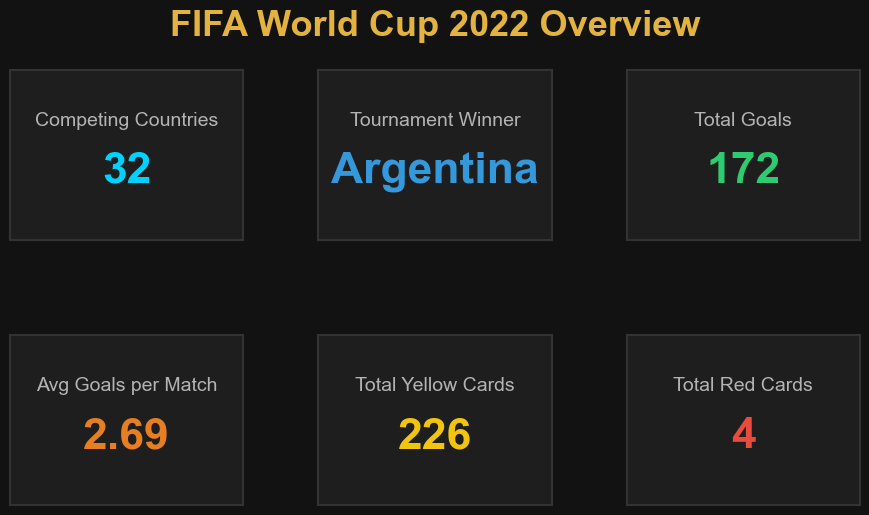

In [27]:
# Updated Seaborn theme to dark
sns.set_theme(style="dark", context="talk", palette="muted")

# --- 1. Calculate the Metrics ---
unique_teams = pd.concat([data['team1'], data['team2']]).unique()
num_countries = len(unique_teams)

total_goals = data['number of goals team1'].sum() + data['number of goals team2'].sum()
total_matches = len(data)
avg_goals = total_goals / total_matches

total_yellows = data['yellow cards team1'].sum() + data['yellow cards team2'].sum()
total_reds = data['red cards team1'].sum() + data['red cards team2'].sum()

final_match = data[data['category'].str.contains('Final', case=False, na=False)]
if not final_match.empty:
    winner = "Argentina" 
else:
    winner = "Unknown"

# --- 2. Visualize as a KPI Dashboard using Matplotlib ---

fig, axes = plt.subplots(2, 3, figsize=(10, 6))

# CHANGE 1: Dark background for the entire figure
fig.patch.set_facecolor('#121212') 

# CHANGE 2: Added the requested gold color to the title
fig.suptitle('FIFA World Cup 2022 Overview', fontsize=26, fontweight='bold', y=0.95, color='#e3b341')

# Prepare the data dictionary (Tweaked a few colors to be brighter for dark mode)
kpis = [
    {"title": "Competing Countries", "value": num_countries, "color": "#00d2ff"}, # Changed from dark blue to bright cyan
    {"title": "Tournament Winner", "value": winner, "color": "#3498db"}, # Lighter blue
    {"title": "Total Goals", "value": int(total_goals), "color": "#2ecc71"}, # Brighter green
    {"title": "Avg Goals per Match", "value": round(avg_goals, 2), "color": "#e67e22"}, # Brighter orange
    {"title": "Total Yellow Cards", "value": int(total_yellows), "color": "#f1c40f"}, # Brighter yellow
    {"title": "Total Red Cards", "value": int(total_reds), "color": "#e74c3c"} # Brighter red
]

for ax, kpi in zip(axes.flatten(), kpis):
    # CHANGE 3: Dark grey background for the individual cards
    ax.set_facecolor('#1e1e1e') 
    
    # CHANGE 4: Darker borders for the cards so they blend well
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')
        spine.set_linewidth(1.5)
        
    # Title Text (Lightened the grey so it is readable on the dark background)
    ax.text(0.5, 0.7, kpi["title"], fontsize=14, ha='center', va='center', color='#b3b3b3')
    
    # Value Text
    ax.text(0.5, 0.4, kpi["value"], fontsize=32, ha='center', va='center', fontweight='bold', color=kpi["color"])
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout(pad=3.0)
plt.subplots_adjust(top=0.85)

plt.show()

## Knockout stages

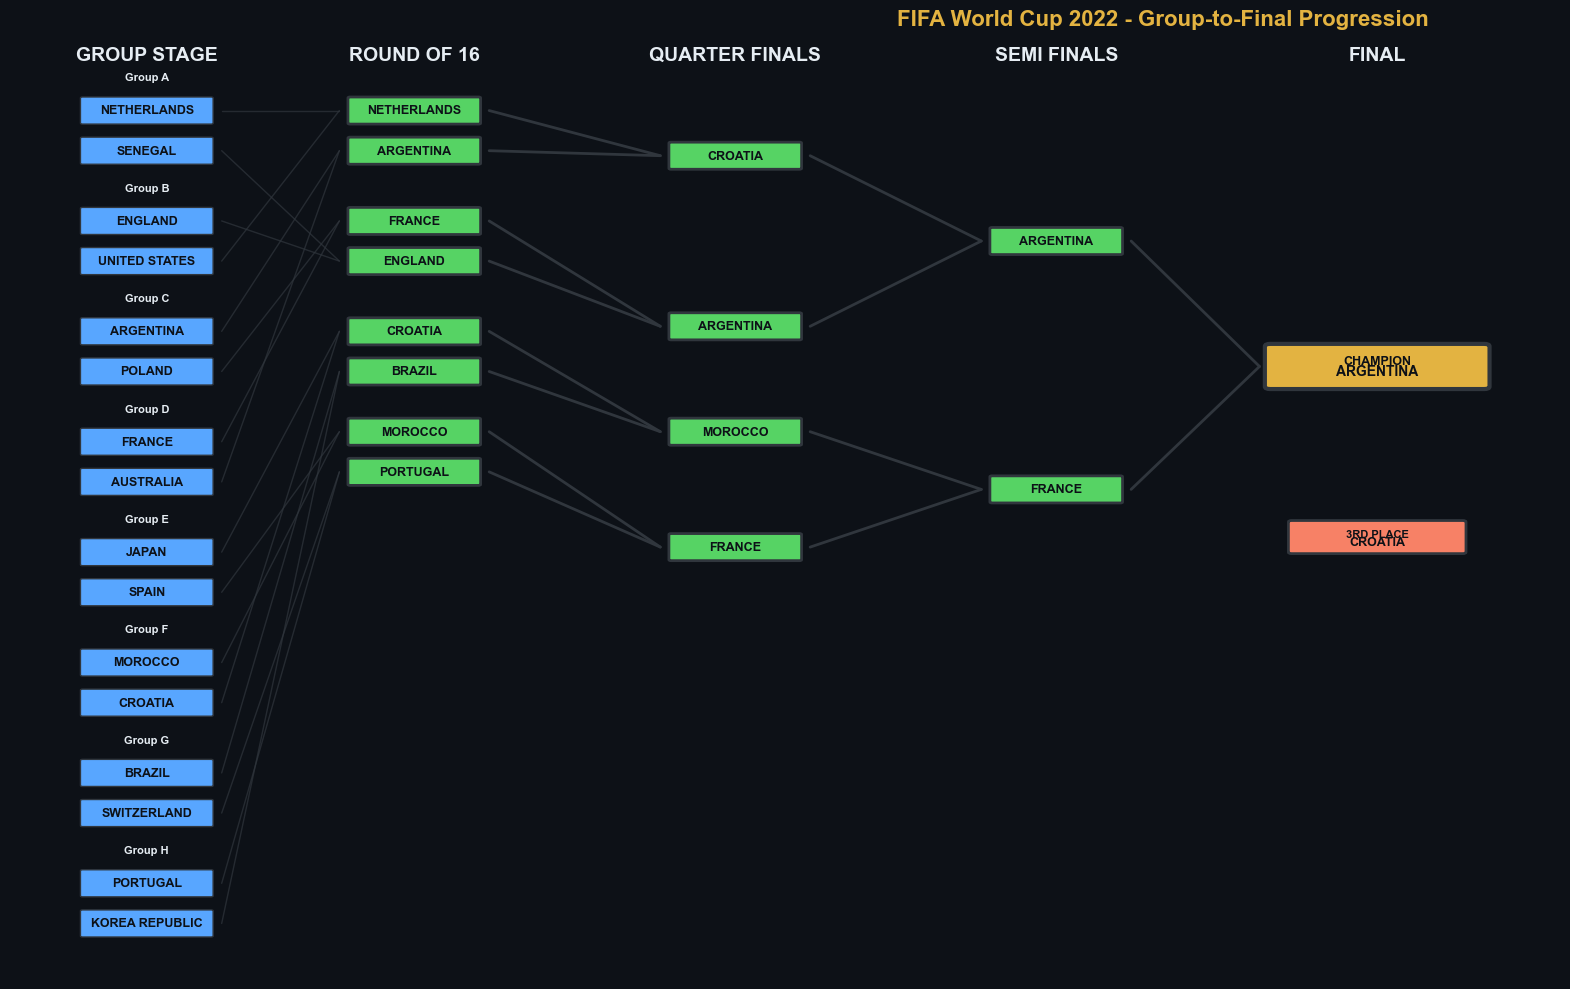

In [24]:
stage_order = [
    "Round of 16",
    "Quarter-final",
    "Semi-final",
    "Final"
]

shootout_winners = {
    ("Final", "ARGENTINA", "FRANCE"): "ARGENTINA",
}


def compute_group_advancers(df):
    groups = sorted(df[df["category"].str.contains("Group")]["category"].unique())
    advancers = {}

    for group in groups:
        group_df = df[df["category"] == group]

        team1 = group_df[["team1", "number of goals team1", "number of goals team2"]].copy()
        team1.columns = ["team", "scored", "conceded"]
        team2 = group_df[["team2", "number of goals team2", "number of goals team1"]].copy()
        team2.columns = ["team", "scored", "conceded"]

        all_teams = pd.concat([team1, team2], ignore_index=True)
        stats = all_teams.groupby("team").agg(
            scored=("scored", "sum"),
            conceded=("conceded", "sum"),
        ).reset_index()
        stats["goal_diff"] = stats["scored"] - stats["conceded"]
        stats["points"] = 0

        for _, row in group_df.iterrows():
            if row["number of goals team1"] > row["number of goals team2"]:
                stats.loc[stats["team"] == row["team1"], "points"] += 3
            elif row["number of goals team1"] < row["number of goals team2"]:
                stats.loc[stats["team"] == row["team2"], "points"] += 3
            else:
                stats.loc[stats["team"] == row["team1"], "points"] += 1
                stats.loc[stats["team"] == row["team2"], "points"] += 1

        stats = stats.sort_values(
            ["points", "goal_diff", "scored", "team"],
            ascending=[False, False, False, True],
        )
        advancers[group] = stats["team"].tolist()[:2]

    return advancers


def get_match_winner(row, next_stage_teams=None):
    team1 = row["team1"]
    team2 = row["team2"]
    score1 = float(row["number of goals team1"])
    score2 = float(row["number of goals team2"])

    if score1 > score2:
        return team1
    if score2 > score1:
        return team2

    if next_stage_teams is not None:
        if team1 in next_stage_teams and team2 not in next_stage_teams:
            return team1
        if team2 in next_stage_teams and team1 not in next_stage_teams:
            return team2

    key = (row["category"], team1, team2)
    if key in shootout_winners:
        return shootout_winners[key]

    key_reversed = (row["category"], team2, team1)
    if key_reversed in shootout_winners:
        return shootout_winners[key_reversed]

    return team1


def build_knockout_progression(df):
    matches = {stage: df[df["category"] == stage].copy().reset_index(drop=True) for stage in stage_order}
    progression = {}

    for i, stage in enumerate(stage_order):
        next_stage_teams = None
        if i + 1 < len(stage_order):
            next_stage_df = matches[stage_order[i + 1]]
            next_stage_teams = set(next_stage_df["team1"].tolist() + next_stage_df["team2"].tolist())

        progression[stage] = []
        for _, row in matches[stage].iterrows():
            progression[stage].append(
                {
                    "team1": row["team1"],
                    "team2": row["team2"],
                    "winner": get_match_winner(row, next_stage_teams),
                }
            )

    progression["Play-off for third place"] = []
    third_df = df[df["category"] == "Play-off for third place"].copy().reset_index(drop=True)
    for _, row in third_df.iterrows():
        progression["Play-off for third place"].append(
            {
                "team1": row["team1"],
                "team2": row["team2"],
                "winner": get_match_winner(row),
            }
        )

    return progression


def plot_bracket(df):
    group_advancers = compute_group_advancers(df)
    progression = build_knockout_progression(df)
    r16_matches = progression["Round of 16"]
    qf_matches = progression["Quarter-final"]
    sf_matches = progression["Semi-final"]
    final_match = progression["Final"][0]
    third_match = progression["Play-off for third place"][0]

    fig, ax = plt.subplots(figsize=(20, 12))
    fig.patch.set_facecolor("#0d1117")
    ax.set_facecolor("#0d1117")
    ax.axis("off")

    group_positions = {}
    y_base = 10.5
    for group, teams in group_advancers.items():
        group_positions[group] = {}
        for idx, team in enumerate(teams):
            x = 0.5
            y = y_base - idx * 0.8
            box = FancyBboxPatch((x - 0.6, y - 0.25), 1.2, 0.5,
                                 boxstyle="round,pad=0.02",
                                 facecolor="#58a6ff", edgecolor="#30363d", linewidth=1)
            ax.add_patch(box)
            ax.text(x, y, team, ha="center", va="center",
                    fontsize=9, color="#0d1117", fontweight="bold")
            group_positions[group][team] = (x + 0.7, y)

        ax.text(0.5, y_base + 0.6, group, ha="center", fontsize=8,
                color="#e6edf3", fontweight="bold")
        y_base -= 2.2

    r16_positions = [
        (3, 10.5), (3, 9.7), (3, 8.3), (3, 7.5),
        (3, 6.1), (3, 5.3), (3, 4.1), (3, 3.3),
    ]

    for idx, match in enumerate(r16_matches):
        x, y = r16_positions[idx]
        box = FancyBboxPatch((x - 0.6, y - 0.25), 1.2, 0.5,
                             boxstyle="round,pad=0.02",
                             facecolor="#56d364", edgecolor="#30363d", linewidth=2)
        ax.add_patch(box)
        ax.text(x, y, match["winner"], ha="center", va="center",
                fontsize=9, color="#0d1117", fontweight="bold")

        for team in [match["team1"], match["team2"]]:
            group_name = next((g for g, teams in group_advancers.items() if team in teams), None)
            if group_name is not None and team in group_positions[group_name]:
                sx, sy = group_positions[group_name][team]
                ax.plot([sx, x - 0.7], [sy, y], color="#30363d", linewidth=1, alpha=0.7)

    qf_positions = [
        (6, 9.6), (6, 6.2), (6, 4.1), (6, 1.8)
    ]
    for idx, match in enumerate(qf_matches):
        x, y = qf_positions[idx]
        box = FancyBboxPatch((x - 0.6, y - 0.25), 1.2, 0.5,
                             boxstyle="round,pad=0.02",
                             facecolor="#56d364", edgecolor="#30363d", linewidth=2)
        ax.add_patch(box)
        ax.text(x, y, match["winner"], ha="center", va="center",
                fontsize=9, color="#0d1117", fontweight="bold")

        r16_a = r16_positions[idx * 2]
        r16_b = r16_positions[idx * 2 + 1]
        ax.plot([r16_a[0] + 0.7, x - 0.7], [r16_a[1], y], color="#30363d", linewidth=2)
        ax.plot([r16_b[0] + 0.7, x - 0.7], [r16_b[1], y], color="#30363d", linewidth=2)

    sf_positions = [(9, 7.9), (9, 2.95)]
    for idx, match in enumerate(sf_matches):
        x, y = sf_positions[idx]
        box = FancyBboxPatch((x - 0.6, y - 0.25), 1.2, 0.5,
                             boxstyle="round,pad=0.02",
                             facecolor="#56d364", edgecolor="#30363d", linewidth=2)
        ax.add_patch(box)
        ax.text(x, y, match["winner"], ha="center", va="center",
                fontsize=9, color="#0d1117", fontweight="bold")

        qf_a = qf_positions[idx * 2]
        qf_b = qf_positions[idx * 2 + 1]
        ax.plot([qf_a[0] + 0.7, x - 0.7], [qf_a[1], y], color="#30363d", linewidth=2)
        ax.plot([qf_b[0] + 0.7, x - 0.7], [qf_b[1], y], color="#30363d", linewidth=2)

    final_pos = (12, 5.4)
    box = FancyBboxPatch((final_pos[0] - 1, final_pos[1] - 0.4), 2, 0.8,
                         boxstyle="round,pad=0.05",
                         facecolor="#e3b341", edgecolor="#30363d", linewidth=3)
    ax.add_patch(box)
    ax.text(final_pos[0], final_pos[1] + 0.1, "CHAMPION",
            ha="center", va="center", fontsize=9, color="#0d1117", fontweight="bold")
    ax.text(final_pos[0], final_pos[1] - 0.1, final_match["winner"],
            ha="center", va="center", fontsize=10, color="#0d1117", fontweight="bold")

    ax.plot([sf_positions[0][0] + 0.7, final_pos[0] - 1.1], [sf_positions[0][1], final_pos[1]],
            color="#30363d", linewidth=2)
    ax.plot([sf_positions[1][0] + 0.7, final_pos[0] - 1.1], [sf_positions[1][1], final_pos[1]],
            color="#30363d", linewidth=2)

    third_pos = (12, 2)
    box = FancyBboxPatch((third_pos[0] - 0.8, third_pos[1] - 0.3), 1.6, 0.6,
                         boxstyle="round,pad=0.03",
                         facecolor="#f78166", edgecolor="#30363d", linewidth=2)
    ax.add_patch(box)
    ax.text(third_pos[0], third_pos[1] + 0.05, "3RD PLACE",
            ha="center", va="center", fontsize=8, color="#0d1117", fontweight="bold")
    ax.text(third_pos[0], third_pos[1] - 0.1, third_match["winner"],
            ha="center", va="center", fontsize=9, color="#0d1117", fontweight="bold")

    ax.text(0.5, 11.5, "GROUP STAGE", ha="center", fontsize=14, color="#e6edf3", fontweight="bold")
    ax.text(3, 11.5, "ROUND OF 16", ha="center", fontsize=14, color="#e6edf3", fontweight="bold")
    ax.text(6, 11.5, "QUARTER FINALS", ha="center", fontsize=14, color="#e6edf3", fontweight="bold")
    ax.text(9, 11.5, "SEMI FINALS", ha="center", fontsize=14, color="#e6edf3", fontweight="bold")
    ax.text(12, 11.5, "FINAL", ha="center", fontsize=14, color="#e6edf3", fontweight="bold")

    ax.text(10, 12.2, "FIFA World Cup 2022 - Group-to-Final Progression",
            ha="center", fontsize=16, color="#e3b341", fontweight="bold")

    # plt.tight_layout()
    plt.savefig("worldcup_progression_from_dataframe.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()

plot_bracket(data)


## Tactical Style of the top #2 countries

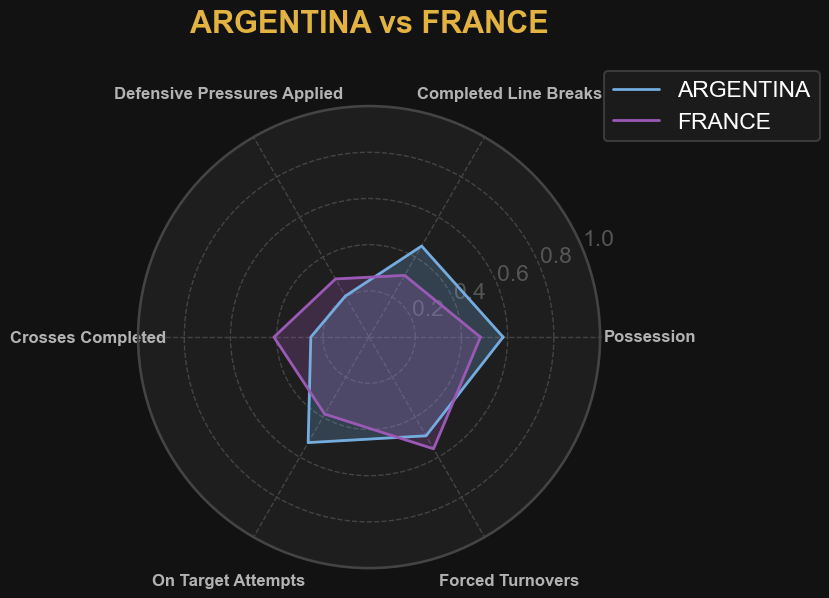

In [46]:
# 1. Data preparation
# For this example, these represent Argentina's hypothetical averages per match
# In reality, you would group your dataframe by the team and calculate the mean
categories = ['Possession %', 'Line Breaks', 'Pressures', 'Crosses', 'Shots on Target', 'Forced Turnovers']

def get_team_stats(df, team_name):
    """
    Extracts all matches for a specific team and aligns their stats 
    into unified columns, regardless of whether they were team1 or team2.
    """
    # 1. Isolate the games where the target team played
    df_team1 = df[df['team1'] == team_name].copy()
    df_team2 = df[df['team2'] == team_name].copy()
    
    # 2. Automatically find all the metric names by looking for ' team1'
    # This captures 'possession', 'passes', 'yellow cards', etc.
    base_metrics = [c.replace(' team1', '') for c in df.columns if c.endswith(' team1')]
    
    # 3. Rename the columns for the games where they were Team 1
    for m in base_metrics:
        df_team1[m] = df_team1[f'{m} team1']
        df_team1[f'opponent {m}'] = df_team1[f'{m} team2']
        
    # 4. Rename the columns for the games where they were Team 2
    for m in base_metrics:
        df_team2[m] = df_team2[f'{m} team2']
        df_team2[f'opponent {m}'] = df_team2[f'{m} team1']
        
    # 5. Combine the rows back together
    team_df = pd.concat([df_team1, df_team2], ignore_index=True)
    
    # 6. Create a clean 'opponent_name' column for easy plotting later
    team_df['opponent_name'] = np.where(team_df['team1'] == team_name, team_df['team2'], team_df['team1'])
    
    # 7. Filter down to just our clean, unified columns
    cols_to_keep = ['category', 'date', 'opponent_name'] + base_metrics + [f'opponent {m}' for m in base_metrics]
    
    # Only return columns that actually exist to prevent errors
    final_cols = [c for c in cols_to_keep if c in team_df.columns]
    
    return team_df[final_cols]

team_A_name = 'ARGENTINA'
team_B_name = 'FRANCE' 
team_A_data = get_team_stats(data, team_A_name)
team_B_data = get_team_stats(data, team_B_name)


# Now, 'team_A_data' or 'team_B_data' has clean columns like 'possession', 'passes completed', etc.
# Let's get their tournament averages for the Radar Chart:

categories = ['possession', 'completed line breaks', 'defensive pressures applied', 
              'crosses completed', 'on target attempts', 'forced turnovers']

norm_values_A = []
norm_values_B = []

for cat in categories:
    col_team1 = f"{cat} team1"
    col_team2 = f"{cat} team2"
    
    tourney_max = max(data[col_team1].max(), data[col_team2].max())
    tourney_min = min(data[col_team1].min(), data[col_team2].min())
    
    # Calculate Team A
    val_A = team_A_data[cat].mean()
    norm_A = 0 if tourney_max == tourney_min else (val_A - tourney_min) / (tourney_max - tourney_min)
    norm_values_A.append(norm_A)
    
    # Calculate Team B
    val_B = team_B_data[cat].mean()
    norm_B = 0 if tourney_max == tourney_min else (val_B - tourney_min) / (tourney_max - tourney_min)
    norm_values_B.append(norm_B)

# Close the shapes for the radar chart
norm_values_A += norm_values_A[:1]
norm_values_B += norm_values_B[:1]

num_vars = len(categories)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]
plot_labels = [c.title() for c in categories]

# 3. Build the Head-to-Head Chart
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#121212') 
ax.set_facecolor('#1e1e1e')

plt.xticks(angles[:-1], plot_labels, color='#b3b3b3', size=12, fontweight='bold')
ax.tick_params(axis='y', colors='#555555') 
ax.grid(color='#444444', linestyle='--', linewidth=1) 
ax.spines['polar'].set_color('#444444') 
ax.set_ylim(0, 1)

# Plot Team A (Argentina - Light Blue)
ax.plot(angles, norm_values_A, color='#74acdf', linewidth=2, label=team_A_name)
ax.fill(angles, norm_values_A, color='#74acdf', alpha=0.25)

# Plot Team B (France - Deep Blue/Purple so it stands out)
ax.plot(angles, norm_values_B, color='#9b59b6', linewidth=2, label=team_B_name)
ax.fill(angles, norm_values_B, color='#9b59b6', alpha=0.25)

# Formatting
plt.title(f"{team_A_name} vs {team_B_name}", size=22, color='#e3b341', fontweight='bold', y=1.1)
ax.tick_params(pad=20)

# Add a legend so we know which color is which
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1.1), facecolor='#1e1e1e', edgecolor='#444444', labelcolor='white')

plt.show()

## Tactical Correlatoin Matrix

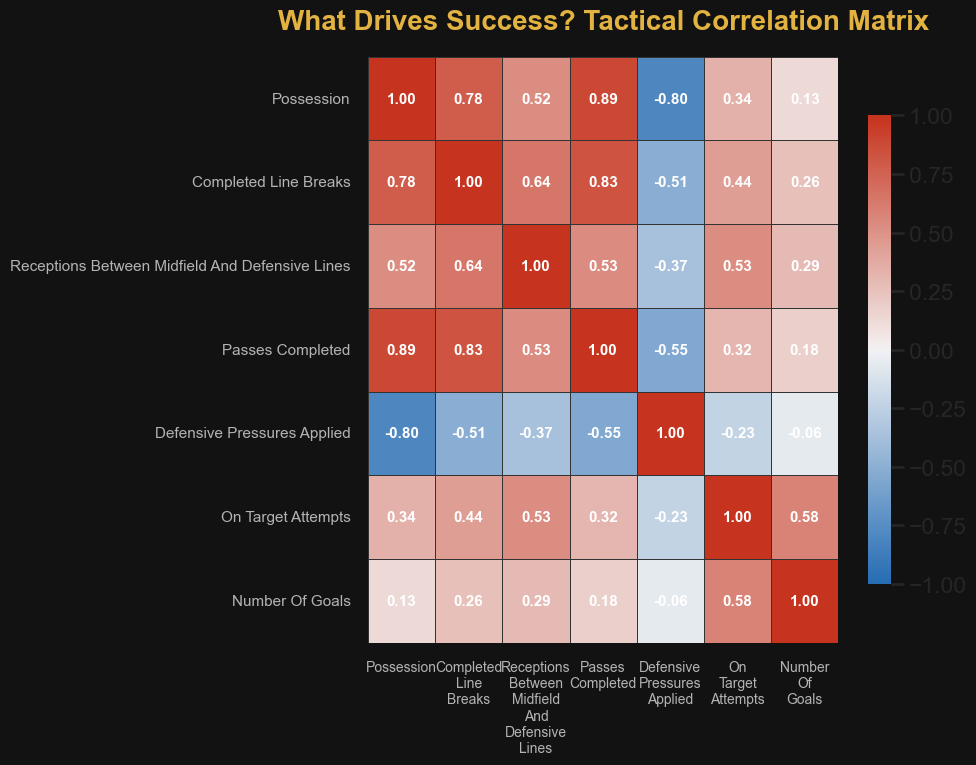

In [52]:
# 1. Select the metrics you want to test for correlation
# We look at both possession metrics, penetration metrics, and outcome metrics
tactical_cols = [
    'possession', 
    'completed line breaks', 
    'receptions between midfield and defensive lines',
    'passes completed',
    'defensive pressures applied',
    'on target attempts',
    'number of goals'
]

# 2. Extract these columns for ALL teams to find the global trends
# (Assuming your 'data' dataframe has already been cleaned from our previous steps)
team1_data = data[[f"{col} team1" for col in tactical_cols]].rename(
    columns={f"{col} team1": col for col in tactical_cols})

team2_data = data[[f"{col} team2" for col in tactical_cols]].rename(
    columns={f"{col} team2": col for col in tactical_cols})

# Combine them so every team's performance in every match is its own row
all_performances = pd.concat([team1_data, team2_data], ignore_index=True)

# 3. Calculate the Correlation Matrix using Pandas
# 'spearman' is often better for sports data than 'pearson' because sports stats 
# aren't always perfectly linear, but '.corr()' defaults to pearson which is fine too.
corr_matrix = all_performances.corr()

# 4. Build the Dark Mode Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#121212') 
ax.set_facecolor('#1e1e1e')

# Create a mask so we only show the bottom triangle (avoids duplicate data)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Generate a custom diverging colormap (Cyan for negative, Dark background, Gold for positive)
cmap = sns.diverging_palette(250, 15, s=90, l=45, as_cmap=True)

# Draw the heatmap
sns.heatmap(corr_matrix, 
            cmap=cmap, 
            vmax=1.0, 
            vmin=-1.0, 
            center=0,
            annot=True, # Show the actual correlation numbers
            fmt=".2f",  # 2 decimal places
            annot_kws={"size": 11, "weight": "bold", "color": "white"},
            linewidths=0.5, 
            linecolor='#333333',
            cbar_kws={"shrink": .8}) # Shrink the colorbar slightly

# Formatting
plt.title("What Drives Success? Tactical Correlation Matrix", 
          color='#e3b341', size=20, fontweight='bold', pad=20)

# Clean up the axis labels to look professional
ax.set_xticklabels([label.get_text().title().replace(' ', '\n') for label in ax.get_xticklabels()], color='#b3b3b3', size=10)
ax.set_yticklabels([label.get_text().title() for label in ax.get_yticklabels()], color='#b3b3b3', size=11)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Movement Profile

In [53]:
# 1. Define the movement columns we want to analyze
movement_metrics = ['inbehind offers to receive', 'inbetween offers to receive', 'infront offers to receive']

# 2. Extract stats for ALL teams using a loop (or apply our get_team_stats logic)
all_teams = pd.concat([data['team1'], data['team2']]).unique()
movement_list = []

for team in all_teams:
    # Use the function we built earlier to get unified columns for this team
    t_data = get_team_stats(data, team)
    
    # Calculate the average for the 3 movement types
    avg_movement = t_data[movement_metrics].mean()
    avg_movement['team'] = team
    movement_list.append(avg_movement)

# 3. Create the final "Movement Profile" dataframe
movement_df = pd.DataFrame(movement_list).set_index('team')

# Clean up column names for the chart (remove ' offers to receive')
movement_df.columns = [c.replace(' offers to receive', '').title() for c in movement_df.columns]

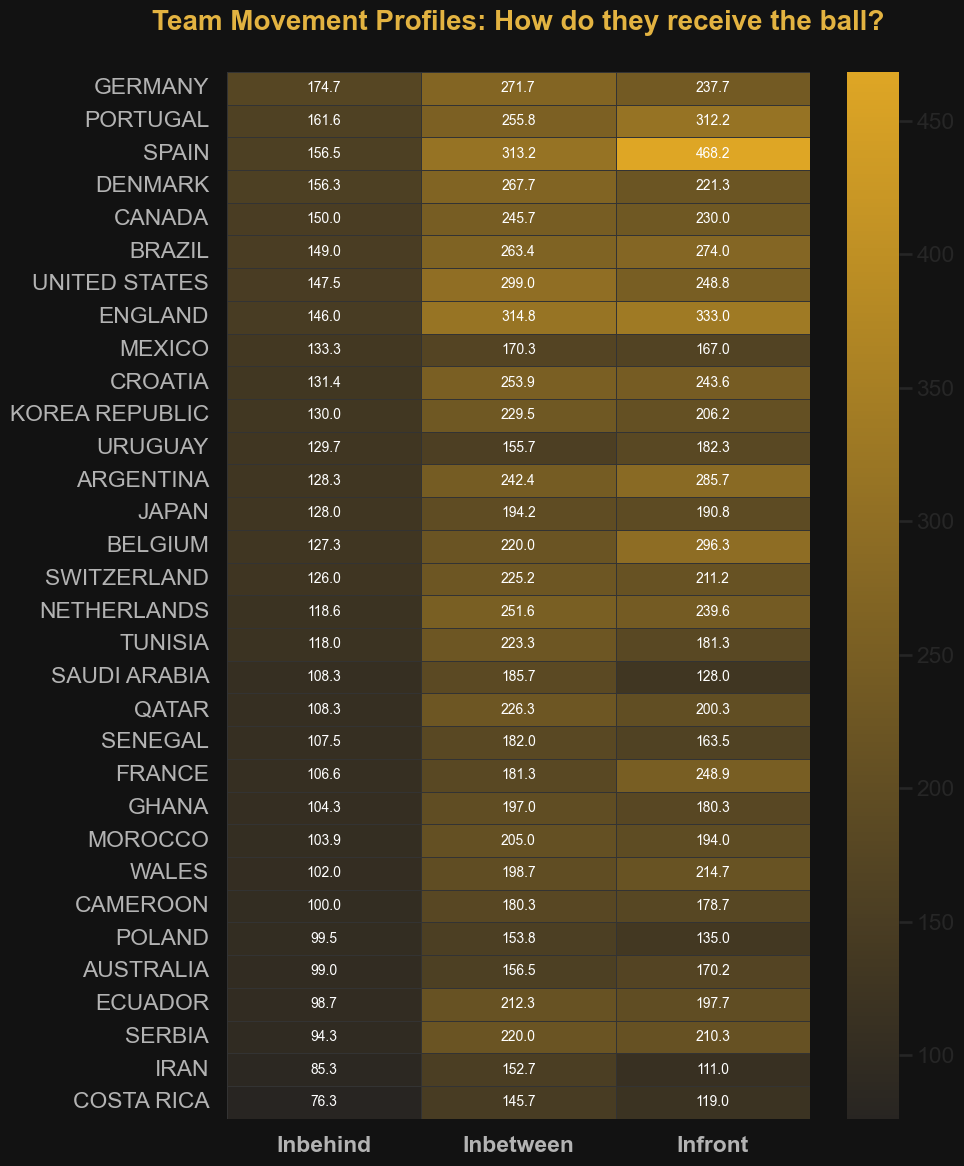

In [58]:
# Sort by Inbehind runs to make the heatmap tell a clearer story
movement_df = movement_df.sort_values('Inbehind', ascending=False)

# 4. Setup the Figure
fig, ax = plt.subplots(figsize=(10, 12)) # Tall figure to fit many countries
fig.patch.set_facecolor('#121212') 
ax.set_facecolor('#1e1e1e')

# Define the custom Red colormap (no brown!)
# We use a sequential palette since these are counts, not correlations
cmap = sns.dark_palette("#dea625", as_cmap=True)

# 5. Draw the Heatmap
sns.heatmap(movement_df, 
            annot=True, 
            fmt=".1f", 
            cmap=cmap, 
            linewidths=0.5, 
            linecolor='#333333',
            annot_kws={"size": 10, "color": "white"})

# 6. Formatting & Title
plt.title("Team Movement Profiles: How do they receive the ball?", 
          color='#e3b341', size=20, fontweight='bold', pad=30)

# Adjust Axis Labels
ax.set_xticklabels(ax.get_xticklabels(), color='#b3b3b3', fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), color='#b3b3b3', rotation=0)
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

## Analyze errors

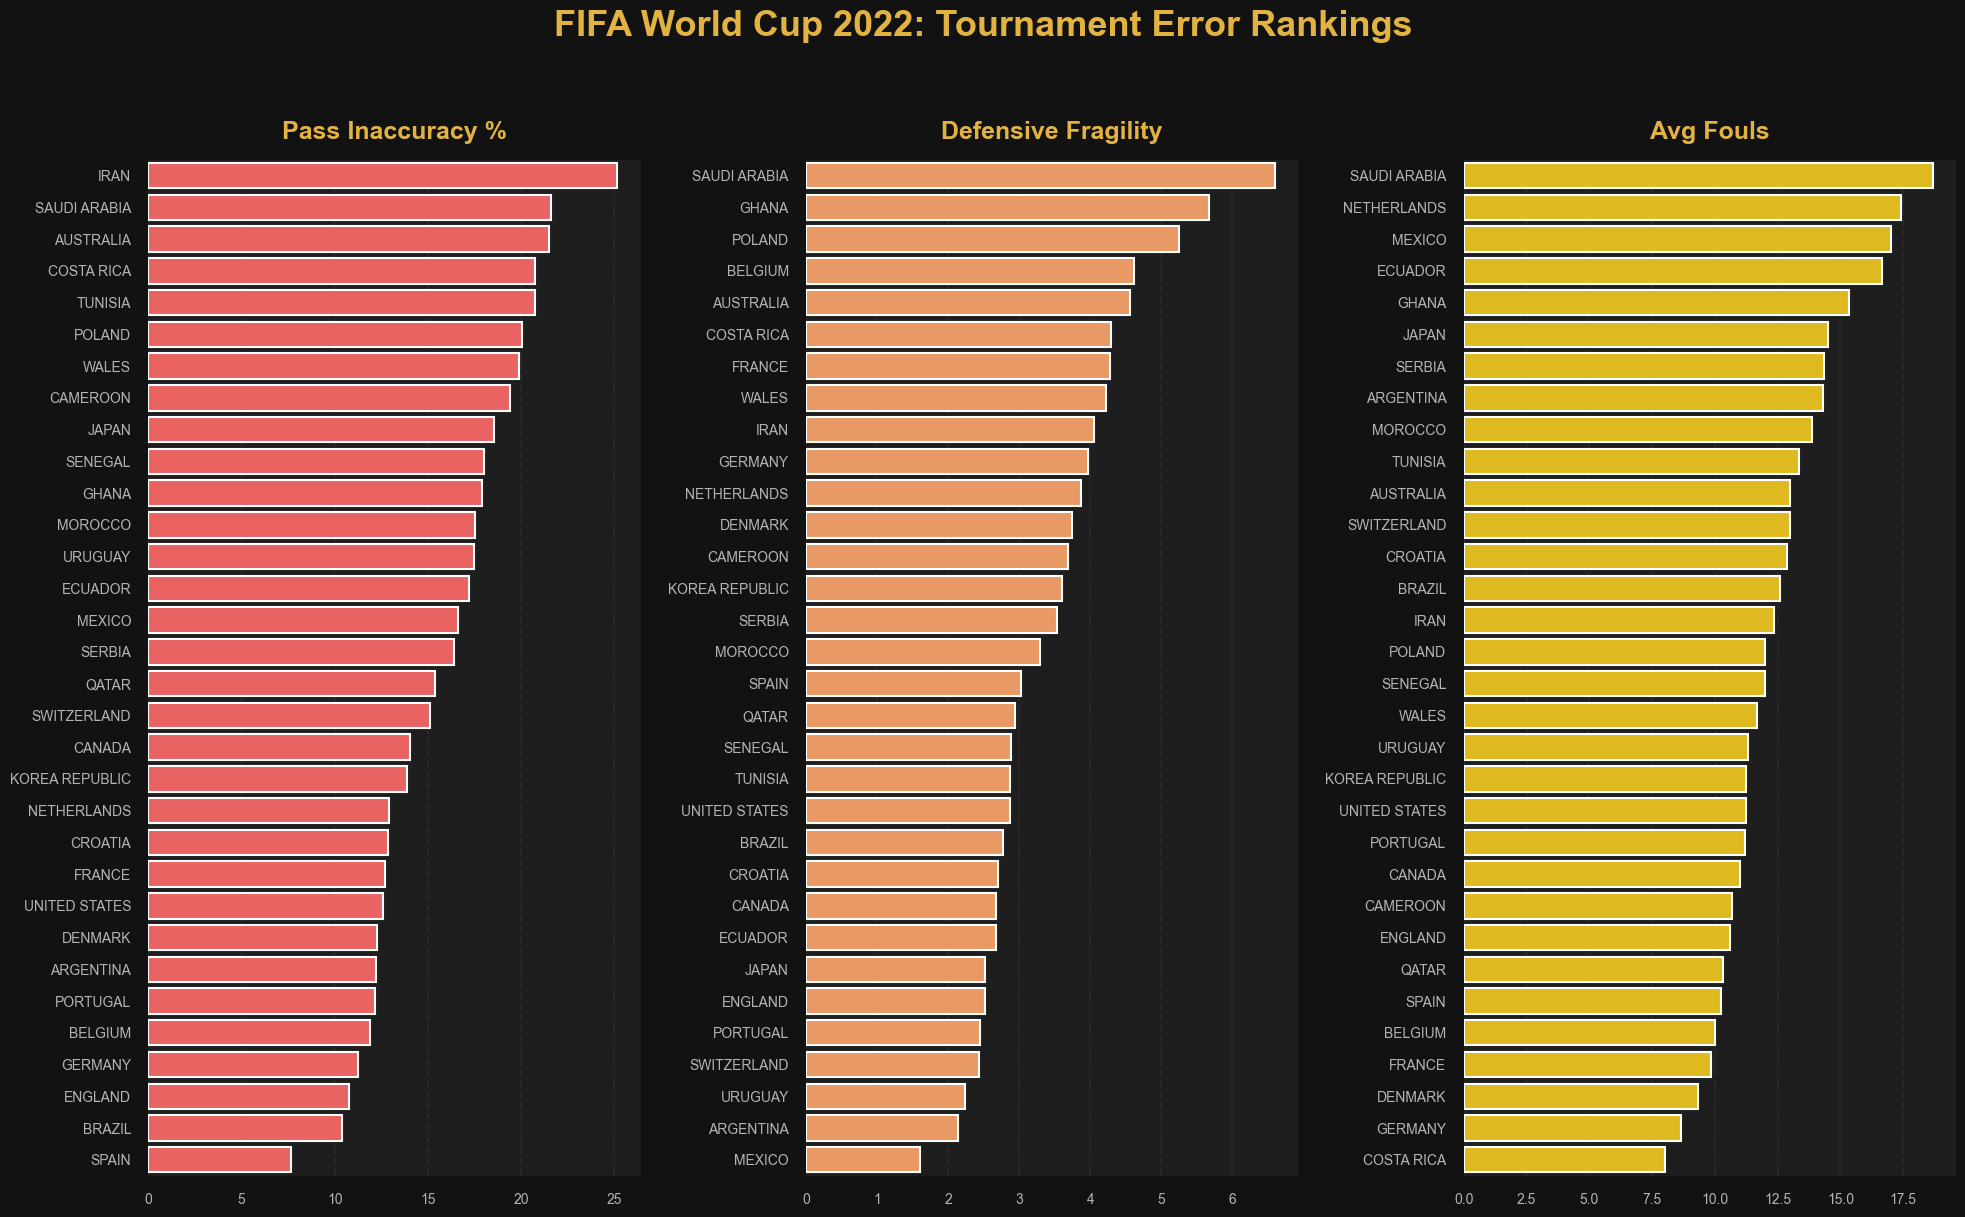

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Collect all unique teams
all_teams = sorted(pd.concat([data['team1'], data['team2']]).unique())

error_stats = []

# 2. Loop through every team to calculate metrics
for team in all_teams:
    t_data = get_team_stats(data, team)
    
    # Technical Error: % of passes that failed
    pass_error = 100 - (t_data['passes completed'].sum() / t_data['passes'].sum() * 100)
    
    # Tactical Error: Defensive Line Breaks conceded per 100 pressures
    # We use 'opponent completed defensive line breaks' because that's what was done TO them
    def_fragility = (t_data['opponent completed defensive line breaks'].sum() / t_data['defensive pressures applied'].sum()) * 100
    
    # Discipline Error: Average fouls committed per match
    avg_fouls = t_data['fouls against'].mean()
    
    error_stats.append({
        'Team': team,
        'Pass Inaccuracy %': pass_error,
        'Defensive Fragility': def_fragility,
        'Avg Fouls': avg_fouls
    })

# Convert to DataFrame for plotting
df_errors = pd.DataFrame(error_stats)

# 3. Create a 3-Panel Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 12))
fig.patch.set_facecolor('#121212')

# Define titles and columns to plot
metrics = ['Pass Inaccuracy %', 'Defensive Fragility', 'Avg Fouls']
colors = ['#ff4d4d', '#ff944d', '#ffcc00'] # Shades of red/orange/yellow

for i, metric in enumerate(metrics):
    # Sort data for each specific chart
    sorted_df = df_errors.sort_values(metric, ascending=False)
    
    ax = axes[i]
    ax.set_facecolor('#1e1e1e')
    
    sns.barplot(data=sorted_df, x=metric, y='Team', ax=ax, color=colors[i])
    
    # Formatting
    ax.set_title(metric, color='#e3b341', fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(colors='#b3b3b3', labelsize=10)
    
    # Remove borders
    sns.despine(ax=ax, left=True, bottom=True)
    
    # Add gridlines for readability
    ax.grid(axis='x', color='#333333', linestyle='--', alpha=0.5)

plt.suptitle("FIFA World Cup 2022: Tournament Error Rankings", 
             color='#e3b341', fontsize=26, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

## Goals VS. Possession

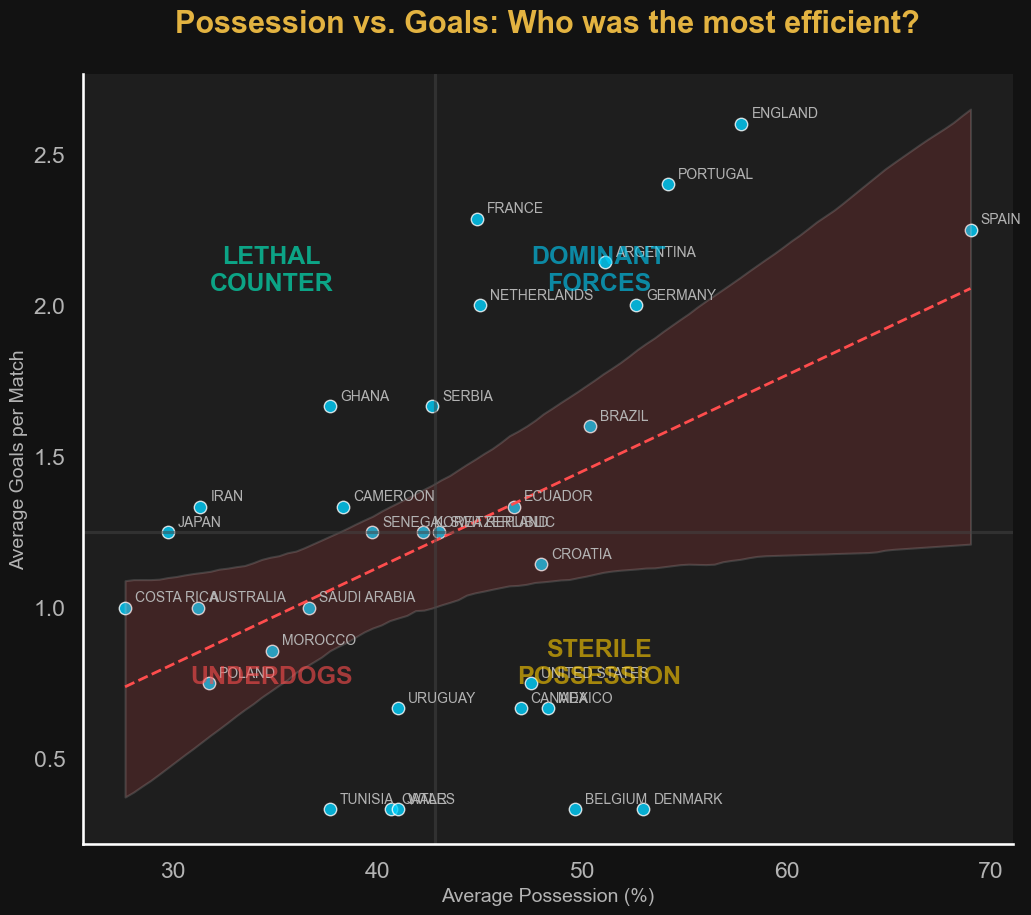

In [63]:
# 1. Calculate Averages for All Teams
all_teams = sorted(pd.concat([data['team1'], data['team2']]).unique())
efficiency_stats = []

for team in all_teams:
    t_data = get_team_stats(data, team)
    
    avg_possession = t_data['possession'].mean()
    avg_goals = t_data['number of goals'].mean()
    
    efficiency_stats.append({
        'Team': team, 
        'Possession': avg_possession, 
        'Goals': avg_goals
    })

df_eff = pd.DataFrame(efficiency_stats)

# 2. Setup the Dark Mode Plot
fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor('#121212')
ax.set_facecolor('#1e1e1e')

# 3. Create Scatter Plot with Regression Line
# 'regplot' adds the trend line and the "shadow" (confidence interval)
sns.regplot(data=df_eff, x='Possession', y='Goals', 
            scatter_kws={'s': 80, 'color': '#00d2ff', 'edgecolor': 'white'},
            line_kws={'color': '#ff4d4d', 'lw': 2, 'ls': '--'})

plt.axvline(df_eff['Possession'].median(), color='#444444', linestyle='-', alpha=0.5)
plt.axhline(df_eff['Goals'].median(), color='#444444', linestyle='-', alpha=0.5)

# 4. Label the Teams
for i in range(df_eff.shape[0]):
    plt.text(df_eff.Possession[i]+0.5, df_eff.Goals[i]+0.02, 
             df_eff.Team[i], fontsize=10, color='#b3b3b3')

# 5. Annotate the Efficiency Zones
med_x = df_eff['Possession'].median()
med_y = df_eff['Goals'].median()

plt.text(med_x - 8, med_y + 0.8, "LETHAL\nCOUNTER", color='#00ffcc', alpha=0.6, fontweight='bold', ha='center')
plt.text(med_x + 8, med_y + 0.8, "DOMINANT\nFORCES", color='#00d2ff', alpha=0.6, fontweight='bold', ha='center')
plt.text(med_x + 8, med_y - 0.5, "STERILE\nPOSSESSION", color='#ffcc00', alpha=0.6, fontweight='bold', ha='center')
plt.text(med_x - 8, med_y - 0.5, "UNDERDOGS", color='#ff4d4d', alpha=0.6, fontweight='bold', ha='center')

# Formatting
plt.title("Possession vs. Goals: Who was the most efficient?", 
          color='#e3b341', size=22, weight='bold', pad=30)
plt.xlabel("Average Possession (%)", color='#b3b3b3', size=14)
plt.ylabel("Average Goals per Match", color='#b3b3b3', size=14)
ax.tick_params(colors='#b3b3b3')
sns.despine()

plt.show()

## Danger Zone Efficiency

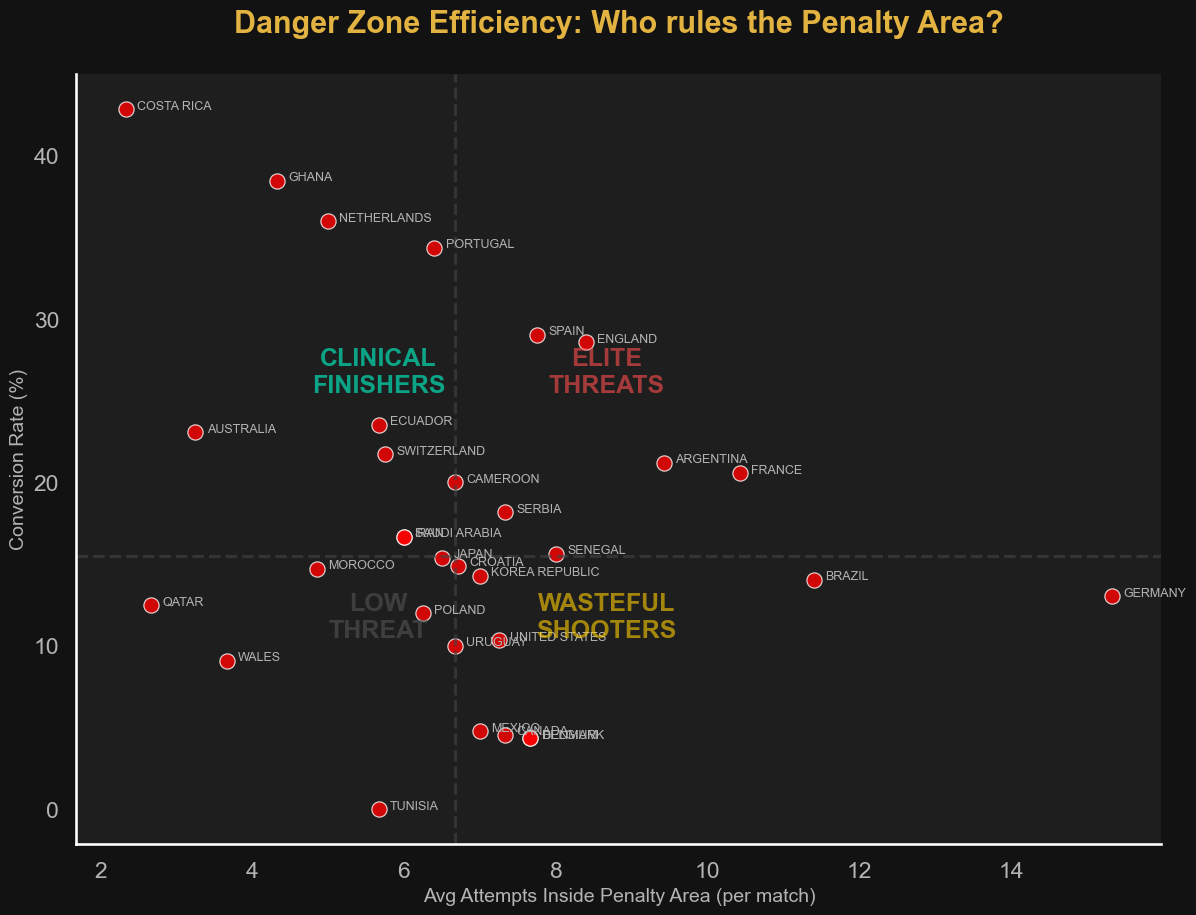

In [64]:
# 1. Prepare the Data
all_teams = sorted(pd.concat([data['team1'], data['team2']]).unique())
dz_stats = []

for team in all_teams:
    t_data = get_team_stats(data, team)
    
    # Sum the totals for the tournament
    total_attempts_in_box = t_data['attempts inside the penalty area'].sum()
    total_goals_in_box = t_data['goal inside the penalty area'].sum()
    
    # Calculate Conversion Rate (Goals / Attempts)
    if total_attempts_in_box > 0:
        conversion_rate = (total_goals_in_box / total_attempts_in_box) * 100
    else:
        conversion_rate = 0
        
    # We use 'mean' for the X-axis to see the average volume per match
    avg_attempts_per_match = t_data['attempts inside the penalty area'].mean()
    
    dz_stats.append({
        'Team': team, 
        'AvgAttempts': avg_attempts_per_match, 
        'ConversionRate': conversion_rate
    })

df_dz = pd.DataFrame(dz_stats)

# 2. Setup the Plot
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('#121212')
ax.set_facecolor('#1e1e1e')

# 3. Create the Scatter Plot
# X-axis = Volume (Attempts per match), Y-axis = Efficiency (Conversion %)
sns.scatterplot(data=df_dz, x='AvgAttempts', y='ConversionRate', 
                s=120, color='#ff0000', edgecolors='white', alpha=0.8)

# 4. Add Quadrant Lines (Tournament Medians)
plt.axvline(df_dz['AvgAttempts'].median(), color='#444444', linestyle='--', alpha=0.6)
plt.axhline(df_dz['ConversionRate'].median(), color='#444444', linestyle='--', alpha=0.6)

# 5. Label the Teams
for i in range(df_dz.shape[0]):
    plt.text(df_dz.AvgAttempts[i] + 0.15, df_dz.ConversionRate[i], 
             df_dz.Team[i], fontsize=9, color='#b3b3b3')

# 6. Annotate the Zones
med_x = df_dz['AvgAttempts'].median()
med_y = df_dz['ConversionRate'].median()

plt.text(med_x - 1, med_y + 10, "CLINICAL\nFINISHERS", color='#00ffcc', fontweight='bold', ha='center', alpha=0.6)
plt.text(med_x + 2, med_y + 10, "ELITE\nTHREATS", color='#ff4d4d', fontweight='bold', ha='center', alpha=0.6)
plt.text(med_x + 2, med_y - 5, "WASTEFUL\nSHOOTERS", color='#ffcc00', fontweight='bold', ha='center', alpha=0.6)
plt.text(med_x - 1, med_y - 5, "LOW\nTHREAT", color='#555555', fontweight='bold', ha='center', alpha=0.6)

# Formatting
plt.title("Danger Zone Efficiency: Who rules the Penalty Area?", 
          color='#e3b341', size=22, weight='bold', pad=30)
plt.xlabel("Avg Attempts Inside Penalty Area (per match)", color='#b3b3b3', size=14)
plt.ylabel("Conversion Rate (%)", color='#b3b3b3', size=14)
ax.tick_params(colors='#b3b3b3')
sns.despine()

plt.show()

## Verticality
(How quickly you move the ball toward the goal)

C:\Users\yarah\AppData\Local\Temp\ipykernel_9992\2295638325.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_v, x='Verticality Index', y='Team', palette='Reds_r')


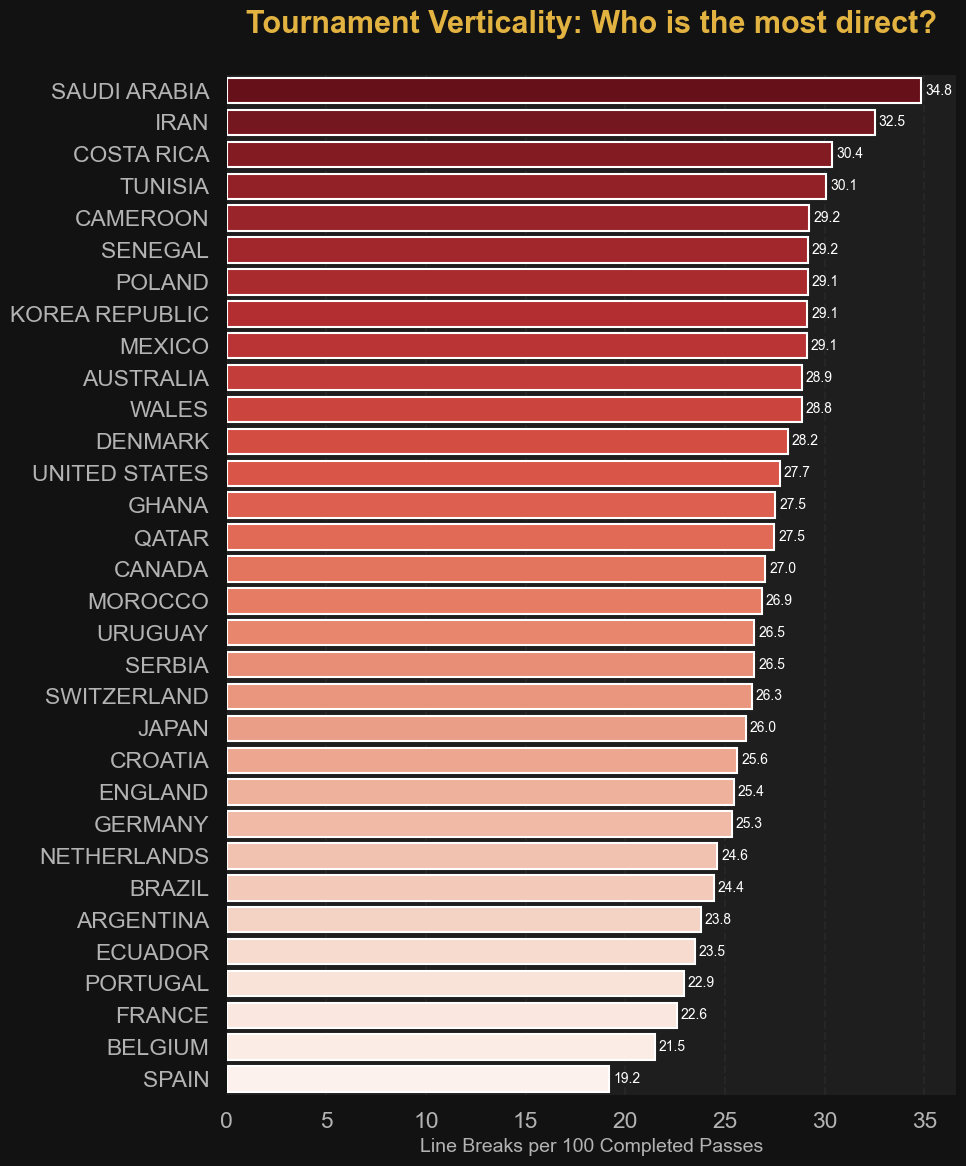

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean the data (Including the specific line break typos)
data.columns = data.columns.str.replace(r'\s+', ' ', regex=True).str.strip()
data.rename(columns={
    'completed line breaksteam1': 'completed line breaks team1',
    'completed line breaksteam2': 'completed line breaks team2'
}, inplace=True)

# 2. Calculate Verticality for all countries
all_teams = sorted(pd.concat([data['team1'], data['team2']]).unique())
v_stats = []

for team in all_teams:
    # Get games as team1 and team2
    t1 = data[data['team1'] == team]
    t2 = data[data['team2'] == team]
    
    # Sum total tournament successful passes and line breaks
    total_passes = t1['passes completed team1'].sum() + t2['passes completed team2'].sum()
    total_breaks = t1['completed line breaks team1'].sum() + t2['completed line breaks team2'].sum()
    
    # Verticality Index: Breaks per 100 passes
    v_index = (total_breaks / total_passes) * 100 if total_passes > 0 else 0
    
    v_stats.append({'Team': team, 'Verticality Index': v_index})



df_v = pd.DataFrame(v_stats).sort_values('Verticality Index', ascending=False)

# 3. Setup the Dark Mode Bar Chart
fig, ax = plt.subplots(figsize=(10, 12))
fig.patch.set_facecolor('#121212')
ax.set_facecolor('#1e1e1e')

# Use a gradient from Red (Very Vertical) to Dark Red
sns.barplot(data=df_v, x='Verticality Index', y='Team', palette='Reds_r')

# 4. Formatting
plt.title("Tournament Verticality: Who is the most direct?", 
          color='#e3b341', size=22, weight='bold', pad=30)
plt.xlabel("Line Breaks per 100 Completed Passes", color='#b3b3b3', size=14)
plt.ylabel("")

# Add value labels to the end of bars
for i, v in enumerate(df_v['Verticality Index']):
    ax.text(v + 0.2, i, f"{v:.1f}", color='white', va='center', size=10)

ax.tick_params(colors='#b3b3b3')
sns.despine(left=True, bottom=True)
ax.grid(axis='x', color='#333333', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Passing Accuracy & Cross Accuracy

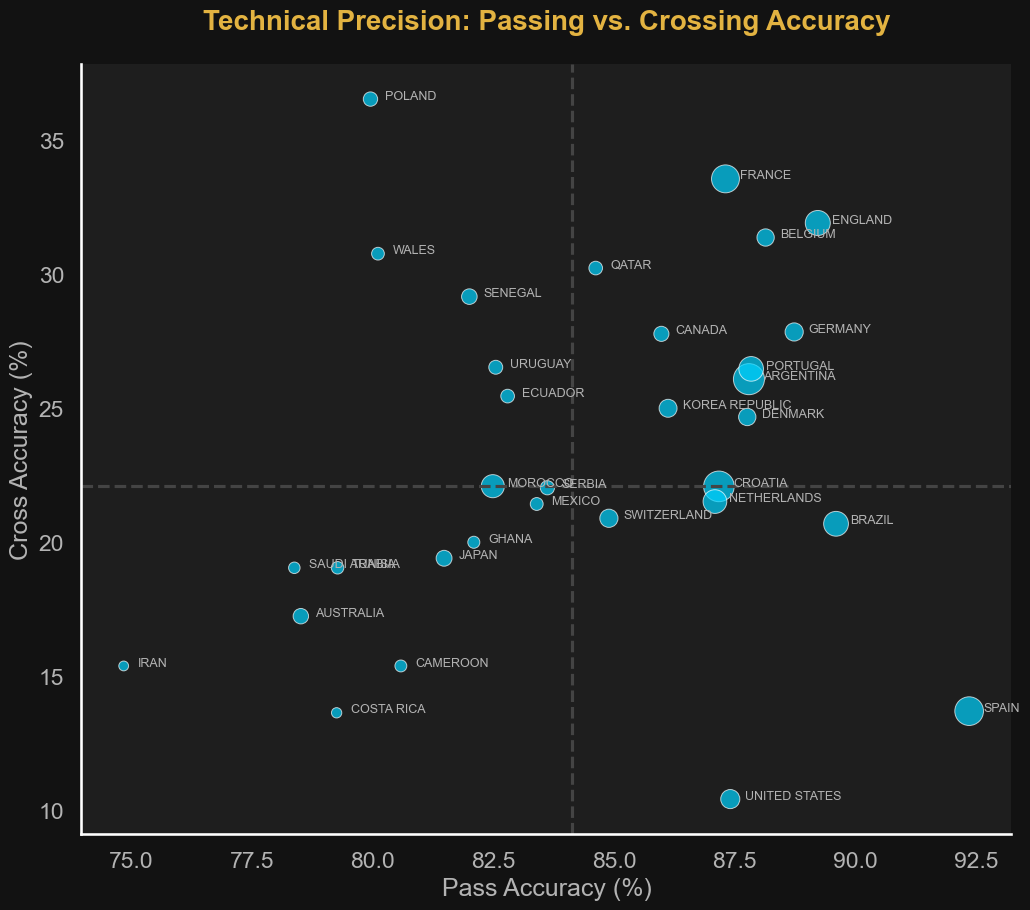

In [71]:
# 1. Calculate accuracy percentages
all_teams = sorted(pd.concat([data['team1'], data['team2']]).unique())
accuracy_stats = []

for team in all_teams:
    t1 = data[data['team1'] == team]
    t2 = data[data['team2'] == team]
    
    # Passing Accuracy
    total_passes = t1['passes team1'].sum() + t2['passes team2'].sum()
    comp_passes = t1['passes completed team1'].sum() + t2['passes completed team2'].sum()
    pass_acc = (comp_passes / total_passes) * 100 if total_passes > 0 else 0
    
    # Crossing Accuracy
    total_crosses = t1['crosses team1'].sum() + t2['crosses team2'].sum()
    comp_crosses = t1['crosses completed team1'].sum() + t2['crosses completed team2'].sum()
    cross_acc = (comp_crosses / total_crosses) * 100 if total_crosses > 0 else 0
    
    accuracy_stats.append({
        'Team': team, 
        'Pass Accuracy': pass_acc, 
        'Cross Accuracy': cross_acc,
        'Total Passes': total_passes # For bubble size
    })

df_acc = pd.DataFrame(accuracy_stats)

# 2. Plotting
fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor('#121212')
ax.set_facecolor('#1e1e1e')

# We'll use the bubble size to show which teams had the ball the most
sns.scatterplot(data=df_acc, x='Pass Accuracy', y='Cross Accuracy', 
                size='Total Passes', sizes=(50, 500), alpha=0.7,
                color='#00d2ff', edgecolor='white', legend=False)

# 3. Add Quadrant Lines (Tournament Medians)
plt.axvline(df_acc['Pass Accuracy'].median(), color='#444444', linestyle='--')
plt.axhline(df_acc['Cross Accuracy'].median(), color='#444444', linestyle='--')

# 4. Label the Teams
for i in range(df_acc.shape[0]):
    plt.text(df_acc['Pass Accuracy'][i] + 0.3, df_acc['Cross Accuracy'][i], 
             df_acc['Team'][i], color='#b3b3b3', fontsize=9)

# Formatting
plt.title("Technical Precision: Passing vs. Crossing Accuracy", 
          color='#e3b341', size=20, weight='bold', pad=25)
plt.xlabel("Pass Accuracy (%)", color='#b3b3b3')
plt.ylabel("Cross Accuracy (%)", color='#b3b3b3')
ax.tick_params(colors='#b3b3b3')
sns.despine()

plt.show()

## Shots on Target

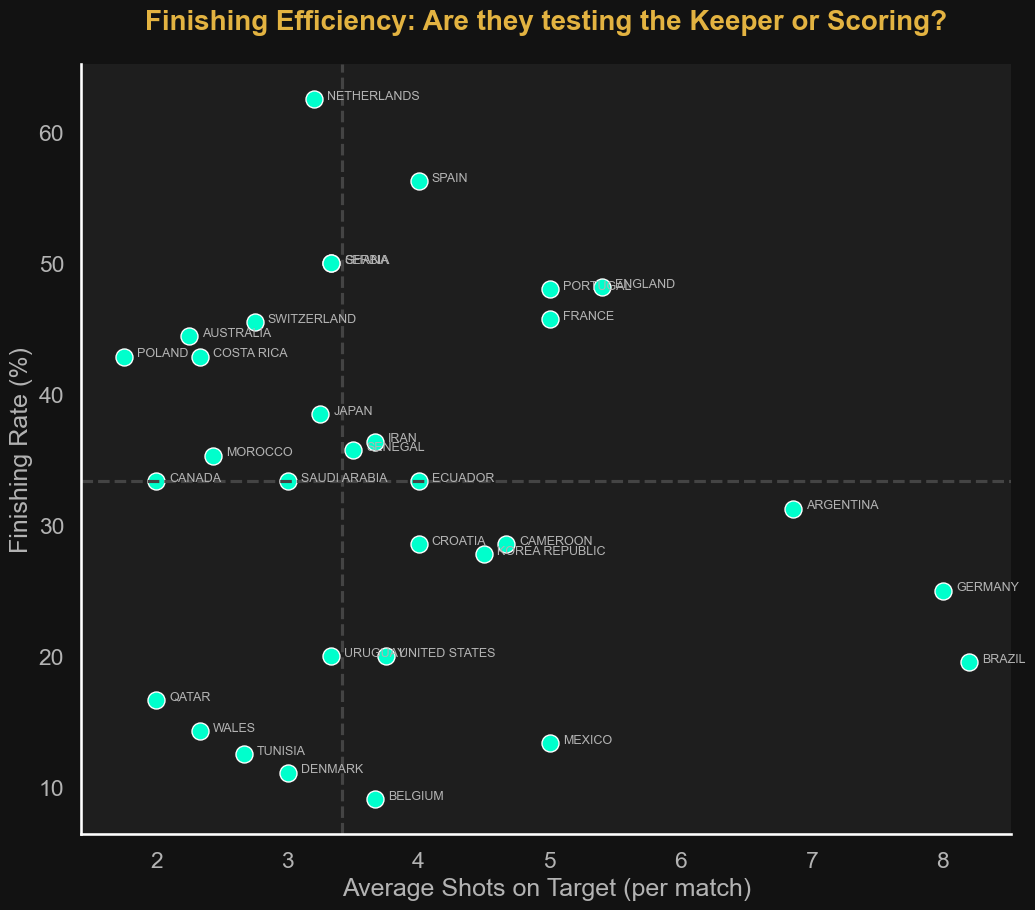

In [72]:
# 1. Calculate the Shooting Stats
all_teams = sorted(pd.concat([data['team1'], data['team2']]).unique())
shooting_stats = []

for team in all_teams:
    t_data = get_team_stats(data, team)
    
    total_sot = t_data['on target attempts'].sum()
    total_goals = t_data['number of goals'].sum()
    
    # Finishing Rate: % of shots on target that resulted in a goal
    finishing_rate = (total_goals / total_sot * 100) if total_sot > 0 else 0
    
    # Average SoT per match (Volume)
    avg_sot = t_data['on target attempts'].mean()
    
    shooting_stats.append({
        'Team': team, 
        'Avg SoT': avg_sot, 
        'Finishing Rate': finishing_rate
    })

df_shoot = pd.DataFrame(shooting_stats)

# 2. Setup Plot
fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor('#121212')
ax.set_facecolor('#1e1e1e')

# 3. Create Scatter Plot
sns.scatterplot(data=df_shoot, x='Avg SoT', y='Finishing Rate', 
                s=150, color='#00ffcc', edgecolor='white')

# 4. Add Median Lines
plt.axvline(df_shoot['Avg SoT'].median(), color='#444444', linestyle='--')
plt.axhline(df_shoot['Finishing Rate'].median(), color='#444444', linestyle='--')

# 5. Labeling
for i in range(df_shoot.shape[0]):
    plt.text(df_shoot['Avg SoT'][i]+0.1, df_shoot['Finishing Rate'][i], 
             df_shoot['Team'][i], color='#b3b3b3', size=9)

# Labels
plt.title("Finishing Efficiency: Are they testing the Keeper or Scoring?", 
          color='#e3b341', size=20, weight='bold', pad=25)
plt.xlabel("Average Shots on Target (per match)", color='#b3b3b3')
plt.ylabel("Finishing Rate (%)", color='#b3b3b3')
ax.tick_params(colors='#b3b3b3')
sns.despine()

plt.show()